# 📊 Data Understanding - Analyse avancée

Ce notebook permet une exploration complète de la DataFrame financière contenant des informations sur les transactions par ISIN, montants, taux, etc.

In [1]:
# === Import des bibliothèques ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

In [10]:
# === Chargement du fichier CSV (à adapter si besoin) ===
df = pd.read_csv(r"C:\Users\zizou\OneDrive\Desktop\stage 3ème\day 2\csvfiles\dataframefinale.csv",sep=";")
df['dataloadingdate'] = pd.to_datetime(df['dataloadingdate'], dayfirst=True)
df['mois'] = df['dataloadingdate'].dt.to_period('M')
df

,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux,mois
0,2025-07-01,TN0008000739,"BTA 7,4% Fevrier 2030",1 459,"1,500",62,"7,600",2025-07
1,2025-07-01,TN0008000739,"BTA 7,4% Fevrier 2030",291,"0,300",183,"7,500",2025-07
2,2025-07-01,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50 000,"5,000",13,"8,600",2025-07
3,2025-07-01,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10 000,"1,000",7,"8,600",2025-07
4,2025-07-01,TN0008000606,"BTA 6,7% Avril 2028",5 660,"5,742",31,"9,100",2025-07
...,...,...,...,...,...,...,...,...
19885,2024-12-31,TN0008000812,"BTA 7,5% 13/12/2028",215,"0,200",50,"9,000",2024-12
19886,2024-12-31,TNX0K9990B08,EMP NAT 2024 T2 CB TF,5 243,"0,556",15,"7,490",2024-12
19887,2024-12-31,TNX0K9990B08,EMP NAT 2024 T2 CB TF,28 288,"3,000",31,"8,990",2024-12
19888,2024-12-31,TNX0K9990B08,EMP NAT 2024 T2 CB TF,48 701,"5,165",31,"8,990",2024-12


## 🔍 Statistiques générales et données manquantes

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19890 entries, 0 to 19889
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   dataloadingdate   19890 non-null  datetime64[ns]
 1   ISIN              19890 non-null  object        
 2   Libellé           19890 non-null  object        
 3   Nombre de Titres  19890 non-null  object        
 4   Montant           19890 non-null  object        
 5   Echéance          19890 non-null  object        
 6   Taux              19890 non-null  object        
 7   mois              19890 non-null  period[M]     
dtypes: datetime64[ns](1), object(6), period[M](1)
memory usage: 1.2+ MB


dataloadingdate     0
ISIN                0
Libellé             0
Nombre de Titres    0
Montant             0
Echéance            0
Taux                0
mois                0
dtype: int64

## 📈 Analyse univariée (Histogrammes & Boxplots)

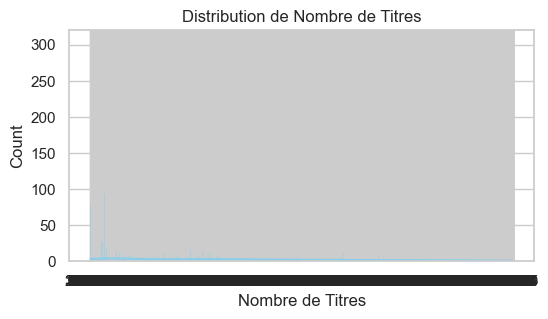

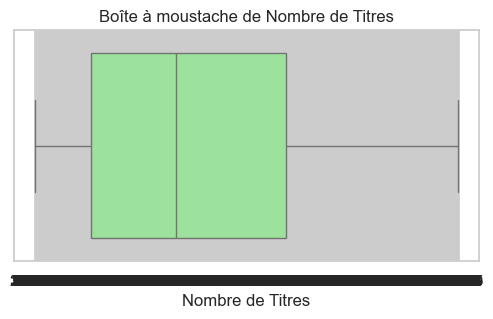

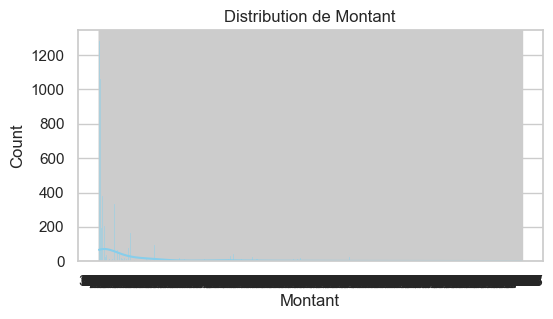

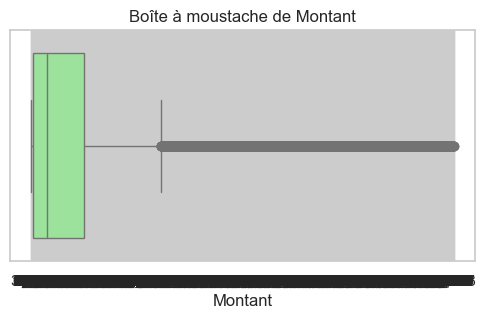

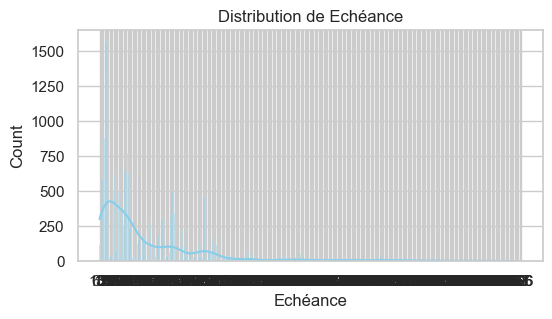

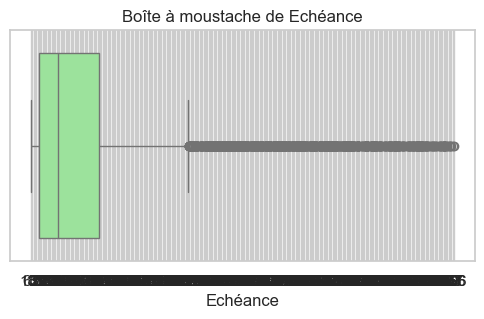

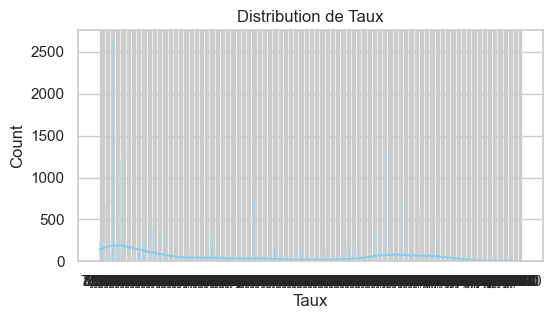

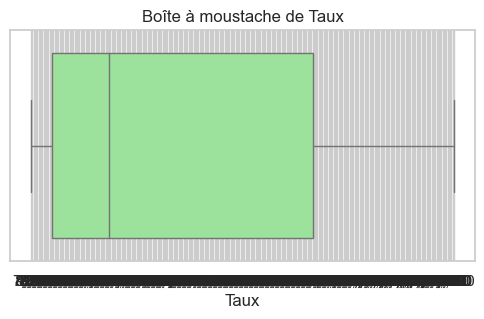

In [ ]:
cols_numeriques = ['Nombre de Titres', 'Montant', 'Echéance', 'Taux']
for col in cols_numeriques:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution de {col}")
    plt.show()

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot {col}")
    plt.show()

## 📅 Analyse temporelle

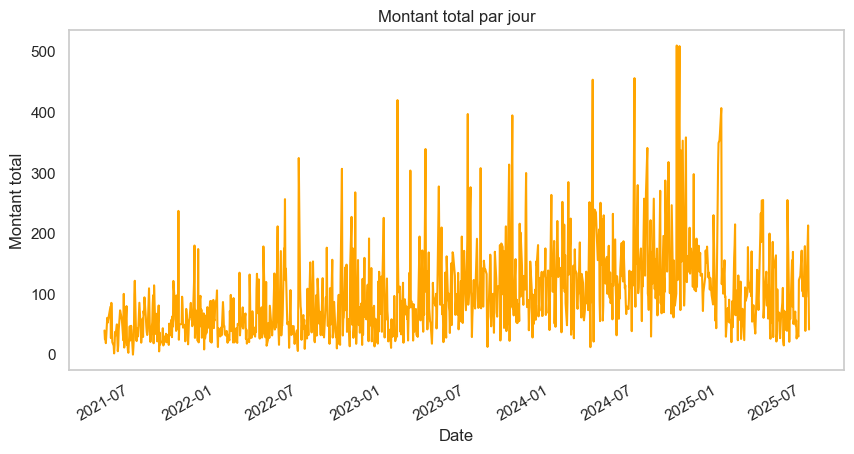

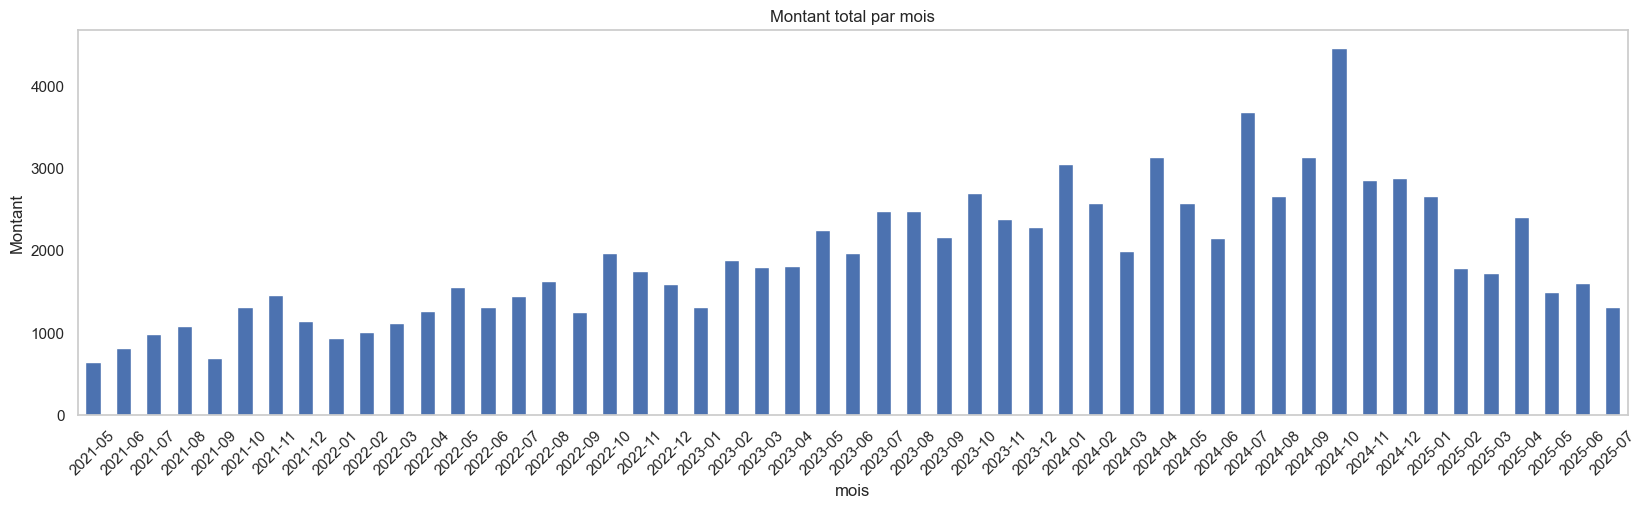

In [12]:
# 🔁 Prétraitement : conversion des types
df['Montant'] = df['Montant'].astype(str).str.replace(',', '.', regex=False)
df['Montant'] = pd.to_numeric(df['Montant'], errors='coerce')
df['dataloadingdate'] = pd.to_datetime(df['dataloadingdate'], dayfirst=True)
df['mois'] = df['dataloadingdate'].dt.to_period('M')

# 📅 Montant total par jour
df_journalier = df.groupby('dataloadingdate')['Montant'].sum()
df_journalier.plot(figsize=(10,5), title="Montant total par jour", color='orange')
plt.xlabel("Date")
plt.ylabel("Montant total")
plt.grid()
plt.show()

# 📆 Montant total par mois
df_mensuel = df.groupby('mois')['Montant'].sum()
df_mensuel.plot(kind='bar', figsize=(20,5), title="Montant total par mois")
plt.ylabel("Montant")
plt.xticks(rotation=45)
plt.grid()
plt.show()


## 🔗 Corrélation et relations entre variables

In [13]:
sns.heatmap(df[cols_numeriques].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

sns.scatterplot(x='Taux', y='Montant', data=df)
plt.title("Montant vs Taux")
plt.show()

sns.scatterplot(x='Nombre de Titres', y='Montant', data=df)
plt.title("Montant vs Nombre de Titres")
plt.show()

ValueError: could not convert string to float: '1 459'

## 📈 Évolution du taux moyen par mois

In [14]:
taux_par_mois = df.groupby('mois')['Taux'].mean()
taux_par_mois.plot(marker='o', figsize=(12,4), title="Évolution du taux moyen par mois")
plt.ylabel("Taux moyen (%)")
plt.grid()
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

## 🚀 Clustering KMeans

In [15]:
features = df[['Montant', 'Taux', 'Nombre de Titres', 'Echéance']].copy()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=0)
df['Cluster'] = kmeans.fit_predict(features_scaled)

sns.scatterplot(x='Taux', y='Montant', hue='Cluster', data=df, palette='tab10')
plt.title("Clustering des transactions")
plt.show()

ValueError: could not convert string to float: '7,600'

## 🔥 Jours d'activité exceptionnelle

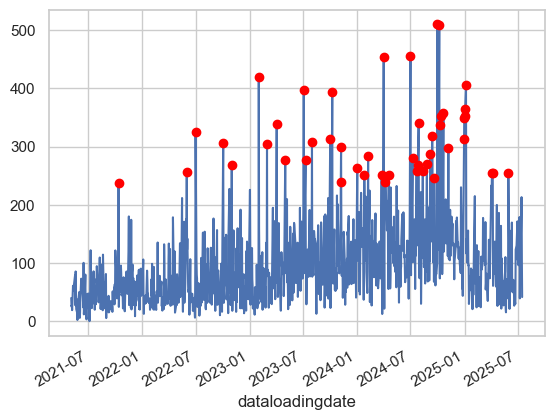

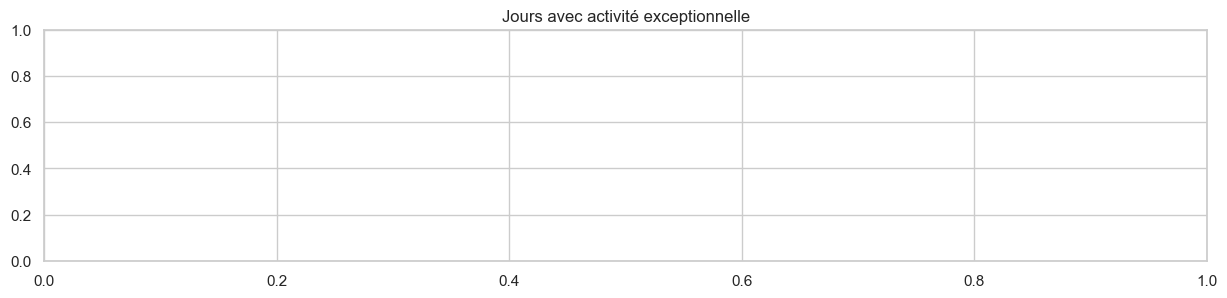

In [ ]:
seuil = df_journalier.mean() + 2 * df_journalier.std()
jours_exceptionnels = df_journalier[df_journalier > seuil]

df_journalier.plot(label="Montant journalier")
jours_exceptionnels.plot(style='o', color='red', label='Jours exceptionnels')
plt.figure(figsize=(15,3))
plt.title("Jours avec activité exceptionnelle")
plt.legend()
plt.show()